# HW3 - Problem 2: Departure-delay classification

## 1. Problem and approach

My goal is to predict whether a flight departs at least 15 minutes late.
The label is 1 when `DEP_DELAY >= 15` and 0 otherwise. The predictors are
weekday, airline, origin, destination, scheduled departure time, scheduled
duration, and distance. Actual departure delay is used only to create the label.

I use a PyTorch neural network with one 64-unit ReLU hidden layer and one output.
KNN with 101 neighbors provides the required comparison. Always predicting a
delay below 15 minutes gives a simple reference for test error. Both fitted
models use fixed settings, separate cutoff calibration, and the same test rows.

To run the notebook, keep `T_ONTIME_REPORTING.csv` and `hw3_split_indices.npz`
beside it, install `requirements.txt`, and run all cells in order. The code uses
CPU execution and seed 42. Exact results can depend on package versions and hardware.

In [1]:
from pathlib import Path
import hashlib
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack
import sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix
from threadpoolctl import threadpool_limits
import torch
from torch import nn
from IPython.display import Markdown, display

CSV_PATH = Path("T_ONTIME_REPORTING.csv")
SPLIT_PATH = Path("hw3_split_indices.npz")
CSV_SHA256 = "e8f309714c1133d2a29ab383d3d7a290113820d8eda061a457338b1f27620846"
SPLIT_SHA256 = "c774e90b55f65372cd94091db17888bbc0c25534ea742f0d904a80b52296a0f5"
SEED = 42
HIDDEN_UNITS = 64
EPOCHS = 9
BATCH_SIZE = 1024
LEARNING_RATE = 0.05
MOMENTUM = 0.9
WEIGHT_DECAY = 0.00003
K = 101

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
thread_limit = threadpool_limits(limits=2)
sklearn.set_config(working_memory=128)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print(f"Python {platform.python_version()} | PyTorch {torch.__version__} | CPU")

Python 3.12.10 | PyTorch 2.14.1+cpu | CPU


## 2. Data preparation

Rows with missing required values are removed. Early departures, extreme
delays, and repeated records are kept. One negative scheduled duration also
remains, which is a known data-quality issue.

I convert local scheduled HHMM time to minutes after midnight. Delay and
duration are in minutes; distance is in miles. The three numeric predictors
are standardized, and the categories are encoded as dummy columns. Fixed
three-hour departure-time bins are included alongside the numeric departure time.

Saved row indices keep the split fixed. The final fit combines 527,748 training
rows and 10,000 validation rows. Separate sets of 10,000 rows each are reserved
for cutoff calibration and testing. Scaling and categories are learned only
from the final fitting rows.

In [2]:
for path, expected_hash in [(CSV_PATH, CSV_SHA256), (SPLIT_PATH, SPLIT_SHA256)]:
    if not path.is_file():
        raise FileNotFoundError(f"Keep {path.name} beside this notebook.")
    if hashlib.sha256(path.read_bytes()).hexdigest() != expected_hash:
        raise ValueError(f"{path.name} does not match the supplied file.")

predictor_columns = [
    "DAY_OF_WEEK", "OP_UNIQUE_CARRIER", "ORIGIN_AIRPORT_ID",
    "DEST_AIRPORT_ID", "CRS_DEP_TIME", "CRS_ELAPSED_TIME", "DISTANCE"
]
required_columns = predictor_columns + ["DEP_DELAY"]
flights = pd.read_csv(CSV_PATH)
clean_data = flights[required_columns].dropna().copy()
clean_data["DepDel15"] = (clean_data["DEP_DELAY"] >= 15).astype(int)
hhmm = clean_data["CRS_DEP_TIME"]
valid_clock = (hhmm >= 0) & (hhmm // 100 < 24) & (hhmm % 100 < 60) & (hhmm % 1 == 0)
assert valid_clock.all()
assert np.isfinite(clean_data.select_dtypes(include="number")).all().all()

with np.load(SPLIT_PATH, allow_pickle=False) as saved:
    split_indices = {name: saved[name] for name in saved.files}
all_indices = np.concatenate(list(split_indices.values()))
assert len(np.unique(all_indices)) == len(all_indices)
assert np.isin(all_indices, clean_data.index).all()
training_data = clean_data.loc[split_indices["training"]].copy()
validation_data = clean_data.loc[split_indices["validation"]].copy()
calibration_data = clean_data.loc[split_indices["calibration"]].copy()
test_data = clean_data.loc[split_indices["test"]].copy()
final_training = pd.concat([training_data, validation_data])

print(f"Original rows: {len(flights):,}; missing-value rows removed: {len(flights) - len(clean_data):,}")
print(f"Complete rows: {len(clean_data):,}")
print(f"Final fitting: {len(final_training):,}; calibration: {len(calibration_data):,}; test: {len(test_data):,}")
del flights, training_data, validation_data, all_indices

Original rows: 597,919; missing-value rows removed: 5,171
Complete rows: 592,748
Final fitting: 537,748; calibration: 10,000; test: 10,000


In [3]:
numeric_columns = ["ScheduledDepartureMinutes", "CRS_ELAPSED_TIME", "DISTANCE"]
category_columns = [
    "DAY_OF_WEEK", "OP_UNIQUE_CARRIER", "ORIGIN_AIRPORT_ID",
    "DEST_AIRPORT_ID", "DepartureTimeBin"
]

def add_features(table):
    table = table.copy()
    hhmm = table["CRS_DEP_TIME"]
    table["ScheduledDepartureMinutes"] = (hhmm // 100) * 60 + hhmm % 100
    table["DepartureTimeBin"] = (table["ScheduledDepartureMinutes"] // 180).astype(int)
    table[category_columns] = table[category_columns].astype(str)
    return table

final_training = add_features(final_training)
scaler = StandardScaler().fit(final_training[numeric_columns])
encoder = OneHotEncoder(handle_unknown="ignore", dtype=np.float32).fit(final_training[category_columns])

def transform_predictors(table):
    numeric = scaler.transform(table[numeric_columns]).astype(np.float32)
    categories = encoder.transform(table[category_columns])
    return hstack([numeric, categories], format="csr", dtype=np.float32)

X_train = transform_predictors(final_training)
y_train = final_training["DepDel15"].to_numpy(dtype=np.float32)
print("Encoded fitting data:", X_train.shape)

Encoded fitting data: (537748, 715)


## 3. Model implementation

The network calculates a hidden layer, an output score, and a probability:

$$h=\max(0,W_1x+b_1),\qquad z=W_2h+b_2,\qquad p=\frac{1}{1+e^{-z}}.$$

Training minimizes binary cross-entropy:

$$L=-\frac{1}{n}\sum_i\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right].$$

`BCEWithLogitsLoss` calculates this loss directly from the output scores.
The network trains for nine epochs with batches of 1,024. SGD uses a learning
rate of 0.05, momentum of 0.9, and L2 weight decay of 0.00003 on all parameters,
including biases. No class weights are used. The training curve shows the
average batch loss within each epoch, excluding the L2 penalty.

KNN uses the same encoded fitting rows, 101 neighbors, equal votes, and
Euclidean distance. Features are stored sparsely to limit memory use;
only the NN batches are converted to dense arrays.

In [4]:
torch.manual_seed(SEED)
network = nn.Sequential(
    nn.Linear(X_train.shape[1], HIDDEN_UNITS),
    nn.ReLU(),
    nn.Linear(HIDDEN_UNITS, 1)
)
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(
    network.parameters(), lr=LEARNING_RATE,
    momentum=MOMENTUM, weight_decay=WEIGHT_DECAY
)
generator = torch.Generator().manual_seed(SEED)
training_losses = []
network.train()
for epoch in range(EPOCHS):
    order = torch.randperm(len(y_train), generator=generator).numpy()
    total_loss = 0.0
    for start in range(0, len(y_train), BATCH_SIZE):
        rows = order[start:start + BATCH_SIZE]
        batch_x = torch.from_numpy(X_train[rows].toarray())
        batch_y = torch.from_numpy(y_train[rows])
        optimizer.zero_grad()
        loss = loss_function(network(batch_x).squeeze(1), batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(rows)
    training_losses.append(total_loss / len(y_train))
print(f"NN training complete: {EPOCHS} epochs.")

knn = KNeighborsClassifier(
    n_neighbors=K, weights="uniform", metric="euclidean",
    algorithm="brute", n_jobs=1
).fit(X_train, y_train)

NN training complete: 9 epochs.


In [5]:
def nn_probabilities(predictors):
    network.eval()
    logits = []
    with torch.no_grad():
        for start in range(0, predictors.shape[0], 4096):
            batch_x = torch.from_numpy(predictors[start:start + 4096].toarray())
            logits.append(network(batch_x).squeeze(1).numpy())
    return torch.sigmoid(torch.from_numpy(np.concatenate(logits))).numpy()

def choose_cutoff(labels, probabilities):
    probabilities = np.asarray(probabilities, dtype=np.float64)
    labels = np.asarray(labels, dtype=np.int64)
    order = np.argsort(probabilities, kind="stable")
    positive_counts = np.r_[0, np.cumsum(labels[order])]
    candidates = np.unique(np.r_[probabilities, 0.0, 0.5, 1.0])
    below = np.searchsorted(probabilities[order], candidates, side="right")
    false_negatives = positive_counts[below]
    false_positives = len(labels) - below - (labels.sum() - false_negatives)
    mistakes = false_negatives + false_positives
    best = np.lexsort((candidates, abs(candidates - 0.5), mistakes))[0]
    return float(candidates[best])

Each probability cutoff is chosen using only the calibration set to minimize
incorrect predictions. False warnings and missed delays have equal cost.
If cutoffs tie, the one closest to 0.5 is chosen, followed by the smaller one.
A probability greater than the cutoff gives class 1; equality gives class 0.
The models remain fixed after this step. This sets the decision cutoff without
changing the probabilities themselves.

In [6]:
calibration_data = add_features(calibration_data)
X_calibration = transform_predictors(calibration_data)
y_calibration = calibration_data["DepDel15"].to_numpy(dtype=np.float32)
calibration_probabilities = {
    "NN": nn_probabilities(X_calibration),
    "KNN": knn.predict_proba(X_calibration)[:, 1]
}
cutoffs = {
    name: choose_cutoff(y_calibration, probabilities)
    for name, probabilities in calibration_probabilities.items()
}
print("Locked cutoffs:", {name: round(value, 6) for name, value in cutoffs.items()})

Locked cutoffs: {'NN': 0.500075, 'KNN': 0.445545}


## 4. Results

Test error is the fraction of incorrect predictions:

$$\text{test error}=\frac{1}{n_{\text{test}}}\sum_i
\mathbf{1}(\hat y_i\ne y_i).$$

For binary labels, this equals the MSE of the predicted classes. AUC measures
how well the scores rank delayed flights. Precision is the fraction of warnings
that are correct; recall is the fraction of delayed flights detected.
The results below use the locked cutoffs, with no model changes based on the
test results. Precision is reported as 0 when a model gives no warnings.

In [7]:
test_data = add_features(test_data)
X_test = transform_predictors(test_data)
y_test = test_data["DepDel15"].to_numpy(dtype=np.float32)
test_probabilities = {
    "NN": nn_probabilities(X_test),
    "KNN": knn.predict_proba(X_test)[:, 1]
}
rows = []
for name, probabilities in test_probabilities.items():
    predictions = (probabilities > cutoffs[name]).astype(int)
    rows.append({
        "Model": name, "Cutoff": cutoffs[name],
        "Test error": np.mean(predictions != y_test),
        "AUC": roc_auc_score(y_test, probabilities),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0)
    })
assert y_train.mean() < 0.5
rows.append({
    "Model": "Always <15 min", "Cutoff": np.nan,
    "Test error": float(y_test.mean()), "AUC": 0.5,
    "Precision": 0.0, "Recall": 0.0
})
results = pd.DataFrame(rows).set_index("Model")
display(results.style.format({
    "Cutoff": "{:.4f}", "Test error": "{:.2%}", "AUC": "{:.4f}",
    "Precision": "{:.2%}", "Recall": "{:.2%}"
}, na_rep="-"))

,Cutoff,Test error,AUC,Precision,Recall
Model,,,,,
NN,0.5001,19.74%,0.7112,57.43%,9.92%
KNN,0.4455,19.79%,0.7117,55.43%,11.85%
Always <15 min,-,20.26%,0.5000,0.00%,0.00%


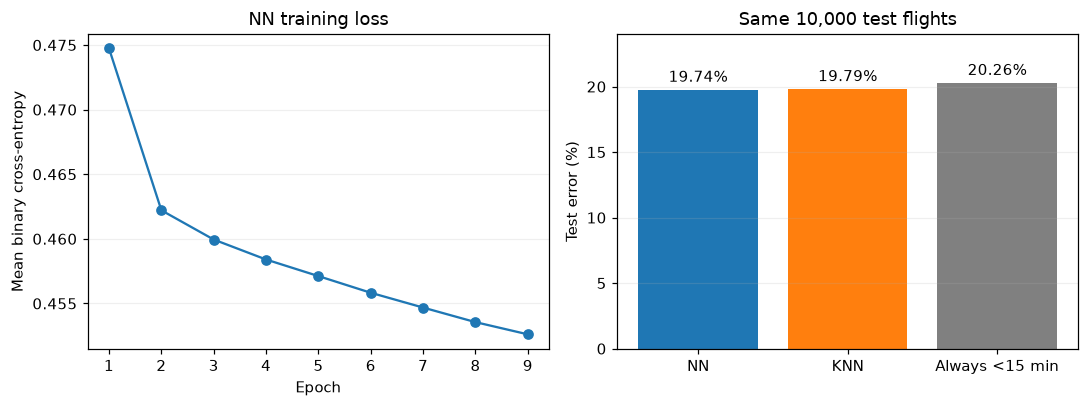

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(range(1, EPOCHS + 1), training_losses, marker="o")
axes[0].set(
    xlabel="Epoch", ylabel="Mean binary cross-entropy",
    title="NN training loss", xticks=range(1, EPOCHS + 1)
)
bars = axes[1].bar(results.index, 100 * results["Test error"], color=["tab:blue", "tab:orange", "gray"])
axes[1].bar_label(bars, fmt="%.2f%%", padding=3)
axes[1].set(ylabel="Test error (%)", title=f"Same {len(y_test):,} test flights", ylim=(0, 24))
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

## 5. Conclusion

In [9]:
nn_result = results.loc["NN"]
nn_predictions = (test_probabilities["NN"] > cutoffs["NN"]).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, nn_predictions, labels=[0, 1]).ravel()
baseline_errors = int(y_test.sum())
nn_errors = int(fp + fn)
display(Markdown(
    f"Over {EPOCHS} epochs, the NN's mean training loss changed "
    f"from **{training_losses[0]:.4f}** to **{training_losses[-1]:.4f}**.\n\n"
    f"On {len(y_test):,} test flights, the NN had **{nn_result['Test error']:.2%} "
    f"error** and **{nn_result['AUC']:.4f} AUC**. KNN had "
    f"**{results.loc['KNN', 'Test error']:.2%} error**. These errors are similar, "
    f"so this one holdout does not show a clear performance advantage. "
    f"The NN made {nn_errors:,} mistakes, {baseline_errors - nn_errors:,} "
    f"fewer than always predicting a delay below 15 minutes.\n\n"
    f"The NN detected **{tp:,} of {int(y_test.sum()):,} delayed flights** "
    f"(**{nn_result['Recall']:.2%} recall**), missed {fn:,}, and gave "
    f"{fp:,} false warnings. **{nn_result['Precision']:.2%}** of its warnings "
    f"were correct. The low recall limits its usefulness as a delay-warning tool."
))

Over 9 epochs, the NN's mean training loss changed from **0.4747** to **0.4526**.

On 10,000 test flights, the NN had **19.74% error** and **0.7112 AUC**. KNN had **19.79% error**. These errors are similar, so this one holdout does not show a clear performance advantage. The NN made 1,974 mistakes, 52 fewer than always predicting a delay below 15 minutes.

The NN detected **201 of 2,026 delayed flights** (**9.92% recall**), missed 1,825, and gave 149 false warnings. **57.43%** of its warnings were correct. The low recall limits its usefulness as a delay-warning tool.

These results describe random rows from one extract and do not establish
accuracy for future months. Date coverage and the independence of repeated
records cannot be verified because dates and flight identifiers are missing.
The predictors also omit weather and operational disruptions.

The model shows some ranking ability but only a small reduction in total
mistakes. These results do not establish the best possible performance within
the assignment scope.